## Project Overview

This project is a continuation of my original Titanic Survival Prediction project. Building on the foundational machine learning pipeline for my earlier Titanic Survival Project I already built. The goal here is to **improve model accuracy t hrough feature engineering**

Instead of relying solely on the raw features provided in the dataset, I will create new, more imformative features by extracting patterns from the existing data - such as passenger titles, family size, age groups, and fare brackets. These engineered features will then be used to retrain a Random Forest classifier with the expectation of achieving a higher validation accuracy than my previous model (81.56%).

This project demonstrates the critical skill of **feature engineering**

# Titanic 2.0: Feature Engineering Challenge

## Goal
Improve the accuracy of my Random Forest model by creating new features from the existing Titanic dataset, using the same train.csv and test.csv files.

## Step by step plan

### Step 1: Data Loading and Cleaning
- Load tran.csv and test.csv
- Drop irrelevant columns: 'cabin, 'ticket'
- Fill missing values:
- 'Age': fill with median from training set
- 'Embarked': fill with mode from training set
- Keep 'Name' for feature extraction (do NOT drop it this time like i did last time)

### Step 2: Feature Engineering (New Features)
- Extract 'Title' from 'Name' (Mr, Mrs, Miss, Master, Rare, etc.)
- Create 'FamilySize' = 'Sibsp' + 'Parch' +1
- Create 'IsAlone' = 1 if 'FamilySize' == 1, else 0
- Bin 'Age' into groups: Child(0-12), Teen(13-18), Adult(19-35), Senior(36-60), Elder (61+)
- Bin 'Fare' into quartiles: Low, Medium, High, Very High

### Step 3: Encode Categorical Features
- Convert 'Sex' to numeric (male=0, female=1)
- Convert 'Embarked' to numeric (S=0, C=1, Q=2)
- Convert 'Title' to numeric (using label encoding)
- Convert 'AgeBin' to numeric (Child=0, Teen=1, Adult=2, Senior=3, Elder)
- Convert 'FareBin' to numeric (Low=0, Medium=1, High=2, Very High=3)

### Step 4: Feature Selection & Target
- Select features: 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBin' FareBin'
-Target: 'Survived'

### Step 5: Data splitting & Scaling
- Split data into training (80%) and validation (20%) sets
- Scale numerical features using 'StandardScaler'

### Step 6: Model Training
- Train a Random Forest Classifier with 100 trees
- Use the same random_state=42 for reproducibility

### Step 7: Evaluation
- Calculate accuracy onvalidation set
- Print classification report (precision, recall, f1-score)
- Compare with previous accuracy (~81.56%)

### Step 8: Predict on Test Set
- Apply same preprocessing to test.csv
- Make predictions
- Save submission as 'titanic_submission_engineered.csv'

## Step 3: Analyze Results
- Check new accuracy
- Look at feature importance from the Random Forest model
- Compare with original results


## Why Feature Engineering Matters

Raw data is rarely in the best format for a machine learning model to learn from. Feature engineering is the art of transforming raw data into meaningful inputs that better represent the underlying problem.

A well-engineered feature can often improve model performance more than switchign to a more complex algorithm.

In [2]:
# ---- Imports -----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#--- Load Data -----
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# ---- Quick Check ----
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nFirst 5 rows of training data:")
print(train_df.head())


Train shape: (891, 12)
Test shape: (418, 11)

First 5 rows of training data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.

^ Here in this first cell, I imported the necessary libraries and loaded the data (through the csv files) into the variables train_df and test_df, i also displayed the number of rows and columns of the data using shape and displayed the first 5 entries using head

In [3]:
#---- Step 1: Clean the data ----

# 1. Drop completely use

In [4]:
# ---- Full data inspection
print("=" * 40)
print("Data Shape and Overview")
print("=" * 40)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


# 2. Missing Values
print("\n" + "=" * 40)
print("Missing Values")
print("="*40)






Data Shape and Overview
Train shape: (891, 12)
Test shape: (418, 11)

Missing Values


In [5]:
# -- making the original data look nicer and storing the nicer view to a file  ----

#-- Set pandas display options for better alignment

pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth',30) 

# 2. Display the raw data with a clean table style


styled_train=train_df.style \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#f0f0f0'), ('border', '1px solid #ddd'), ('padding','8px')]
    }, {
        'selector':'td',
        'props': [('border', '1px solid #ddd'), ('padding', '8px')]
                   
    
    }]) \
    .format({'Fare': '{:.2f}', 'Age': '{:.1f}'}) \
    .hide(axis='index')
          
          
#save to an html file (this will open in the browser)
styled_train.to_html('full_train_data_pleasinglook.html')

print("The data has been made to look nicer and this nicer looking data is stored in an html file. Now viewers can see the data in a more pleasant way")


          
          

The data has been made to look nicer and this nicer looking data is stored in an html file. Now viewers can see the data in a more pleasant way


In [6]:
# ----- Data Audit: Missing Values -----

print('='*50)
print("Missing value count (train set):\n")
print(train_df.isnull().sum())
print('='*50)

print("Missing value count (train set):\n")
print(test_df.isnull().sum())
print('='*50)

#Also show the percentages of missing values for context
print("Missing Percentage of the Train set: ")
print(((train_df.isnull().sum()) / len(train_df)*100))









Missing value count (train set):

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing value count (train set):

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Missing Percentage of the Train set: 
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [7]:
#-- Step 1: Clean the Data (Drop and Fill) ---

# 1. Drop useless columns (they don't help the model predict survival)
train_df = train_df.drop(columns=["Cabin", "Ticket", "PassengerId"], errors='ignore')
test_df = test_df.drop(columns=["Cabin", "Ticket", "PassengerId"], errors='ignore')

# 2. Fill missing age with the median from the training set (never use test stats)
age_median = train_df["Age"].median()
train_df["Age"].fillna(age_median, inplace=True)
test_df["Age"].fillna(age_median, inplace=True)

# 3. Fill missing Emabrked with the mode from the training set
embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'].fillna(embarked_mode, inplace=True)
train_df['Embarked'].fillna(embarked_mode, inplace=True)

# 4. Fill the single missing fare in the test set with the training median
fare_median = train_df['Fare'].median()
test_df["Fare"].fillna(fare_median, inplace=True)

# ---- Final Verification: Confirm no missing values remain -----
print("\n"+"="*50)
print("Final missing value Check (Train):")
print("="*50)
print(train_df.isnull().sum())

print("\n"+"="*50)
print("Final missing value Check (Test):")
print("="*50)
print(test_df.isnull().sum())

 


Final missing value Check (Train):
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Final missing value Check (Test):
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


C:\Users\Bhargav Pokharel\AppData\Local\Temp\ipykernel_23220\2503309106.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Age"].fillna(age_median, inplace=True)
C:\Users\Bhargav Pokharel\AppData\Local\Temp\ipykernel_23220\2503309106.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [8]:
# Step 2: Feature Engineering 

# 1. Extract Title from Name
#Regex to grab the title (e.g, Mr, Mrs, Miss, Master from the Name String)
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

#Group rare titles into a single 'Rare' category
rare_titles = ['Lady', 'Countess', 'Capt','Col', 'Don', 'Dr','Major', 'Rev', 'Sir','Jonkheer','Dona']
train_df['Title'] = train_df['Title'].replace(rare_titles, 'Rare')
test_df['Title'] = test_df['Title'].replace(rare_titles, "Rare")


#Standardize Miss/Mrs/Ms/Mlle/Mme

train_df['Title'] = train_df['Title'].replace(['Mlle','Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme','Mrs')

test_df['Title'] = train_df['Title'].replace(['Mlle','Ms'],'Miss')
test_df['Title'] = test_df['Title'].replace('Mme', 'Mrs')

# 2. Create Family Size
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

#3. Create IsAlone feature
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
test_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

# 4. Bin age into groups

age_bins = [0,12,18,35,60,100]
age_labels = ['Child', 'Teen', 'Adult', 'Senior', 'Elder']
train_df['AgeBin'] = pd.cut(train_df['Age'], bins=age_bins, labels=age_labels)
test_df['AgeBin'] = pd.cut(train_df['Age'], bins=age_bins, labels=age_labels)

# 5. Bin fare into quartiles

train_df['FareBin'] = pd.qcut(train_df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
#for test, use the same bin edges from train
fare_bins = pd.qcut(train_df['Fare'], 4, retbins=True)[1]
test_df['FareBin'] = pd.cut(test_df['Fare'], bins=fare_bins, labels=['Low', 'Medium', 'High', 'Very High'], include_lowest=True)

# Quick check to show new columns
print("\nNew columns added")
print(['Title','FamilySize','IsAlone','AgeBin','FareBin'])
print('\nFirst 5 rows of train_df with new features:')
print(train_df[['Name','Title','Age','AgeBin','Fare','FareBin','FamilySize','IsAlone']].head())






New columns added
['Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin']

First 5 rows of train_df with new features:
                            Name Title   Age  AgeBin     Fare    FareBin  FamilySize  IsAlone
0        Braund, Mr. Owen Harris    Mr  22.0   Adult   7.2500        Low           2        0
1  Cumings, Mrs. John Bradley...   Mrs  38.0  Senior  71.2833  Very High           2        0
2         Heikkinen, Miss. Laina  Miss  26.0   Adult   7.9250     Medium           1        1
3  Futrelle, Mrs. Jacques Hea...   Mrs  35.0   Adult  53.1000  Very High           2        0
4       Allen, Mr. William Henry    Mr  35.0   Adult   8.0500     Medium           1        1


In [9]:
# ---- STEP 3: ENCODE CATEGORICAL FEATURES & PREPARE DATA ----

# 1. Encode Sex and Embarked (already numeric? Let's double-check)
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 2. Encode the NEW engineered features (Title, AgeBin, FareBin)
title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
agebin_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3, 'Elder': 4}
farebin_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}

train_df['Title'] = train_df['Title'].map(title_mapping)
test_df['Title'] = test_df['Title'].map(title_mapping)

train_df['AgeBin'] = train_df['AgeBin'].map(agebin_mapping)
test_df['AgeBin'] = test_df['AgeBin'].map(agebin_mapping)

train_df['FareBin'] = train_df['FareBin'].map(farebin_mapping)
test_df['FareBin'] = test_df['FareBin'].map(farebin_mapping)

# 3. Drop the original 'Name' column (we no longer need it)
train_df = train_df.drop(columns=['Name'])
test_df = test_df.drop(columns=['Name'])

# 4. Prepare Features (X) and Target (y)
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
                'Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin']

X = train_df[feature_cols]
y = train_df['Survived']

X_test = test_df[feature_cols]  # For final predictions later

print("✅ Features and target prepared successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Features and target prepared successfully!
X shape: (891, 12)
y shape: (891,)


In [10]:
# ---- STEP 4: SPLIT, SCALE, AND TRAIN THE NEW MODEL ----

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 3. Train the Random Forest (with the NEW features)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 4. Make predictions
y_pred = rf_model.predict(X_val_scaled)

# 5. Evaluate
accuracy = accuracy_score(y_val, y_pred)
print("=" * 50)
print(f"🔥 NEW Accuracy (with Feature Engineering): {accuracy:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# 6. Show Feature Importance (which new feature helped the most?)
importances = rf_model.feature_importances_
feature_names = X.columns
print("\n🔍 Top 5 Most Important Features:")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {name}: {imp:.4f}")

🔥 NEW Accuracy (with Feature Engineering): 0.8268

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179


🔍 Top 5 Most Important Features:
   Fare: 0.2138
   Age: 0.1843
   Title: 0.1702
   Sex: 0.1496
   Pclass: 0.0659


In [11]:
# ---- FINAL COMPARISON: OLD vs. NEW ----
old_accuracy = 0.8156
new_accuracy = 0.8268

print(f"📉 Old Accuracy (7 features):  {old_accuracy:.4f}")
print(f"📈 New Accuracy (12 features): {new_accuracy:.4f}")
print(f"🏆 Improvement:               {new_accuracy - old_accuracy:.4f} (+{(new_accuracy - old_accuracy)*100:.2f}%)")

📉 Old Accuracy (7 features):  0.8156
📈 New Accuracy (12 features): 0.8268
🏆 Improvement:               0.0112 (+1.12%)


C:\Users\Bhargav Pokharel\AppData\Local\Temp\ipykernel_23220\2584565620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


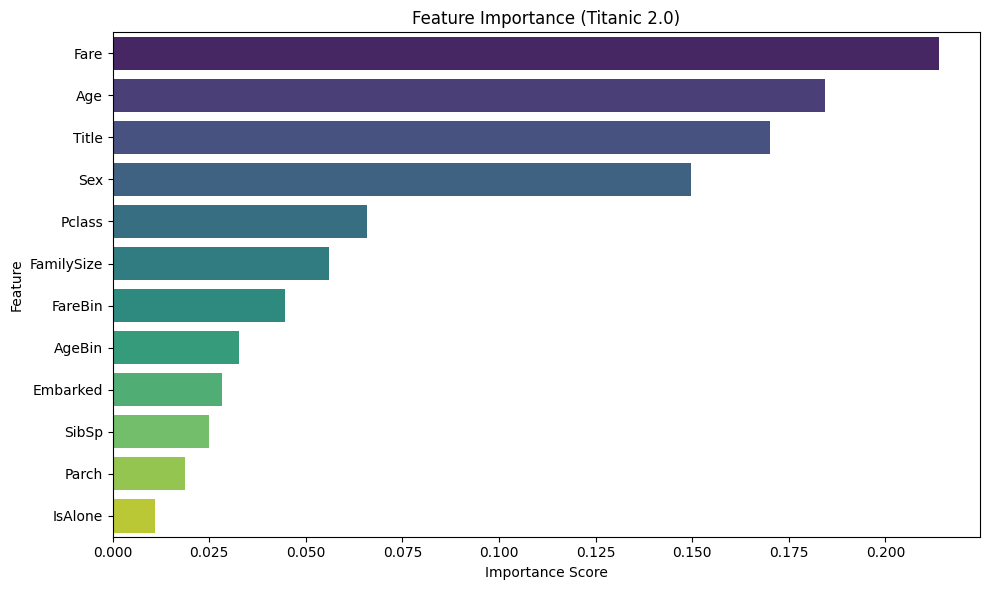

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame of feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Titanic 2.0)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [14]:
import joblib

# Save the trained model and scaler
joblib.dump(rf_model, 'titanic_model_engineered.pkl')
joblib.dump(scaler, 'titanic_scaler_engineered.pkl')

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!
